Coefficients: [[ 0.98208299  0.22519686 -0.36688444  0.0262268  -0.15507824 -0.22867976
  -0.52338614 -0.2793554  -0.22391176 -0.03605388 -0.09476544  1.39135347
  -0.16429246 -0.08903006 -0.02250974  0.04944847 -0.04186075 -0.03193634
  -0.03298528  0.01189208  0.10400464 -0.51389384 -0.01711567 -0.01662253
  -0.30695364 -0.75341491 -1.41533107 -0.50382259 -0.73542849 -0.09913574]]
Intercept: [29.38522795]

--- Binary Classification Metrics ---
Confusion Matrix:
 [[39  4]
 [ 1 70]]
Accuracy: 0.956140350877193
Precision: 0.9459459459459459
Recall: 0.9859154929577465
F1-Score: 0.9655172413793104
ROC-AUC: 0.9977071732721913


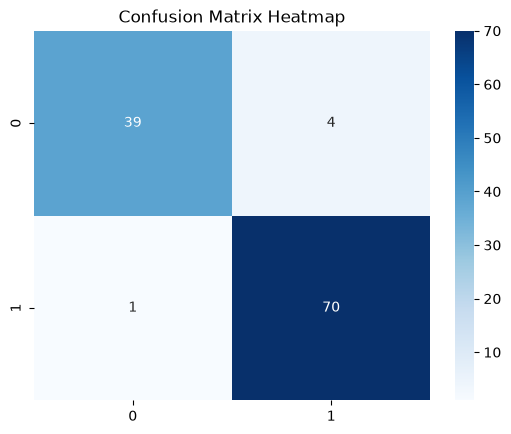

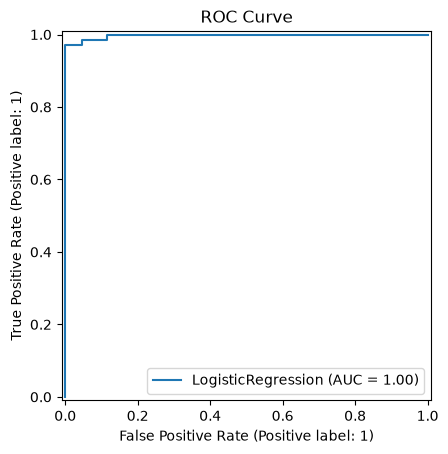


--- Multi-Class Comparison (Iris) ---
Model          Accuracy       F1-Score       
One-vs-Rest    0.9533         0.9533         
Softmax        0.9733         0.9733         


In [1]:
# W3D2: Logistic Regression & Classification
# Gunji Venkatesh

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, RocCurveDisplay
)

# -------------------------------
# 1. Binary Classification (Breast Cancer dataset)
# -------------------------------
# Explicitly request the Bunch object so .data and .target are available.
data = load_breast_cancer(return_X_y=False)
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Predictions
y_pred = model.predict(X_test)

# Metrics
print("\n--- Binary Classification Metrics ---")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

# Confusion Matrix Heatmap
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix Heatmap")
plt.show()

# ROC Curve
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.show()

# -------------------------------
# 2. Multi-Class Classification (Iris dataset)
# -------------------------------
# Explicitly request the Bunch object so .data and .target are available.
iris = load_iris(return_X_y=False)
X, y = iris.data, iris.target

# One-vs-Rest
model_ovr = OneVsRestClassifier(LogisticRegression(max_iter=10000)).fit(X, y)
y_pred_ovr = model_ovr.predict(X)
acc_ovr = accuracy_score(y, y_pred_ovr)
f1_ovr = f1_score(y, y_pred_ovr, average="weighted")

# Softmax (multinomial)
model_softmax = LogisticRegression(solver="lbfgs", max_iter=10000).fit(X, y)
y_pred_softmax = model_softmax.predict(X)
acc_softmax = accuracy_score(y, y_pred_softmax)
f1_softmax = f1_score(y, y_pred_softmax, average="weighted")

# Results Table
print("\n--- Multi-Class Comparison (Iris) ---")
print(f"{'Model':<15}{'Accuracy':<15}{'F1-Score':<15}")
print(f"{'One-vs-Rest':<15}{acc_ovr:<15.4f}{f1_ovr:<15.4f}")
print(f"{'Softmax':<15}{acc_softmax:<15.4f}{f1_softmax:<15.4f}")
